In [1]:
import pandas as pd
import numpy as np
from numpy import argmax
import matplotlib.pyplot as plt
%matplotlib inline
import librosa
import librosa.display
import IPython.display
import pandas as pd
import random
import warnings
import os
from PIL import Image
import pathlib
import csv
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

**features visualization**

In [2]:
audio_data = '/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/Carnatic raga dataset/Anandabhairavi/song_1.mp3'
x, sr = librosa.load(audio_data)
print(type(x), type(sr))

/usr/local/lib/python3.7/dist-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


<class 'numpy.ndarray'> <class 'int'>


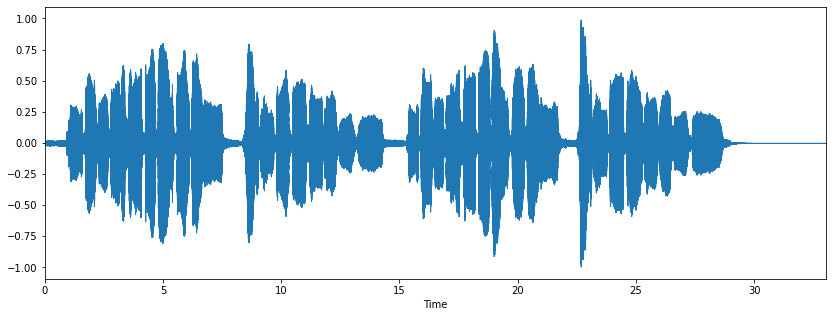

In [3]:
#Visualize an audio file
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
plt.figure(figsize=(14, 5))
librosa.display.waveplot(x, sr=sr)

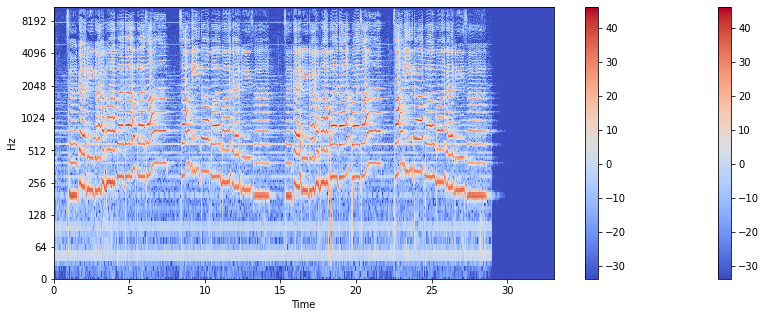

In [4]:
#Spectogram
X = librosa.stft(x)
Xdb = librosa.amplitude_to_db(abs(X))
plt.figure(figsize=(14, 5))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()

librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log')
plt.colorbar()

In [5]:
#audio widget
import IPython.display as ipd
ipd.Audio(audio_data)

In [6]:
#creating an Audio signal
import numpy as np
sr = 22050 # sample rate
T = 5.0    # seconds
t = np.linspace(0, T, int(T*sr), endpoint=False) # time variable
x = 0.5*np.sin(2*np.pi*220*t)# pure sine wave at 220 Hz
#Playing the audio
ipd.Audio(x, rate=sr) # load a NumPy array


/usr/local/lib/python3.7/dist-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


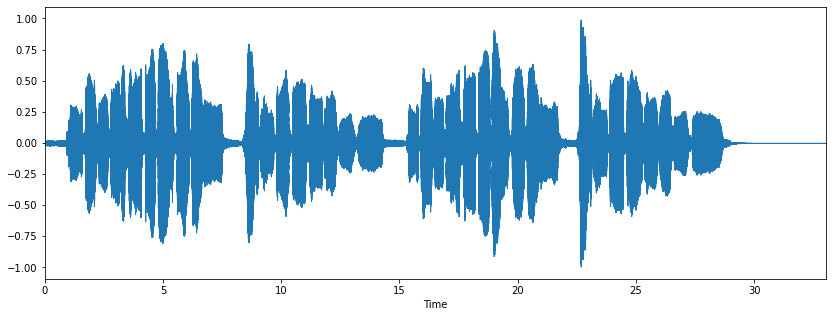

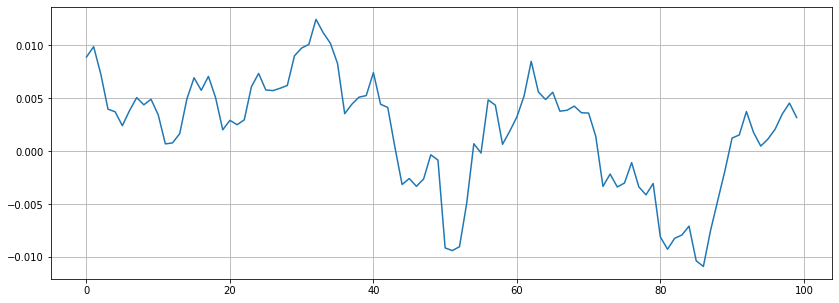

In [7]:
#Feature extraction
# 1.Zero Crossing Rate : The zero crossing rate is the rate of sign-changes along a signal, i.e., the rate at which the signal changes from positive to negative or back.
# Load the signal
x, sr = librosa.load('/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/Carnatic raga dataset/Anandabhairavi/song_1.mp3')
#Plot the signal:
plt.figure(figsize=(14, 5))
librosa.display.waveplot(x, sr=sr)
# Zooming in
n0 = 9000
n1 = 9100
plt.figure(figsize=(14, 5))
plt.plot(x[n0:n1])
plt.grid()

In [ ]:
#2. Spectral Centroid: It indicates where the ”centre of mass” for a sound is located and is calculated as the weighted mean of the frequencies present in the sound.
import sklearn
spectral_centroids = librosa.feature.spectral_centroid(x, sr=sr)[0]
spectral_centroids.shape
(775,)
# Computing the time variable for visualization
frames = range(len(spectral_centroids))
t = librosa.frames_to_time(frames)

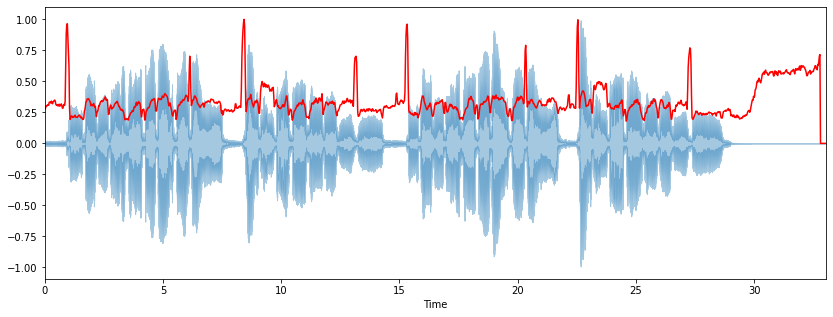

In [ ]:
# Normalising the spectral centroid for visualisation
plt.figure(figsize=(14, 5))
def normalize(x, axis=0):
    return sklearn.preprocessing.minmax_scale(x, axis=axis)
#Plotting the Spectral Centroid along the waveform
librosa.display.waveplot(x, sr=sr, alpha=0.4)
plt.plot(t, normalize(spectral_centroids), color='r')

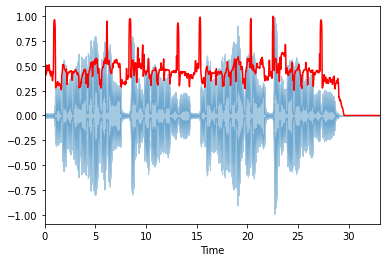

In [ ]:
#3. Spectral Rolloff
#It is a measure of the shape of the signal. It represents the frequency below which a specified percentage of the total spectral energy.
spectral_rolloff = librosa.feature.spectral_rolloff(x+0.01, sr=sr)[0]
librosa.display.waveplot(x, sr=sr, alpha=0.4)
plt.plot(t, normalize(spectral_rolloff), color='r')

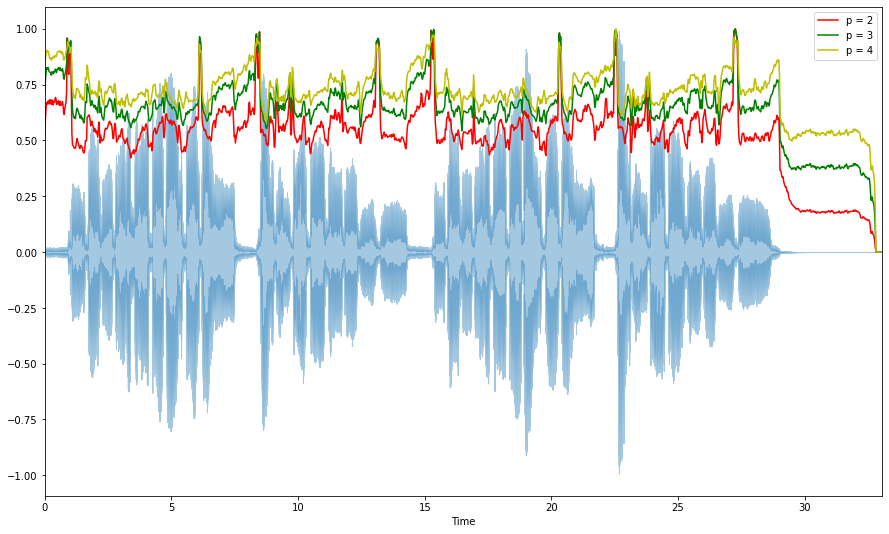

In [ ]:
#4. Spectral Bandwidth
spectral_bandwidth_2 = librosa.feature.spectral_bandwidth(x+0.01, sr=sr)[0]
spectral_bandwidth_3 = librosa.feature.spectral_bandwidth(x+0.01, sr=sr, p=3)[0]
spectral_bandwidth_4 = librosa.feature.spectral_bandwidth(x+0.01, sr=sr, p=4)[0]
plt.figure(figsize=(15, 9))
librosa.display.waveplot(x, sr=sr, alpha=0.4)
plt.plot(t, normalize(spectral_bandwidth_2), color='r')
plt.plot(t, normalize(spectral_bandwidth_3), color='g')
plt.plot(t, normalize(spectral_bandwidth_4), color='y')
plt.legend(('p = 2', 'p = 3', 'p = 4'))

/usr/local/lib/python3.7/dist-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


(20, 1424)


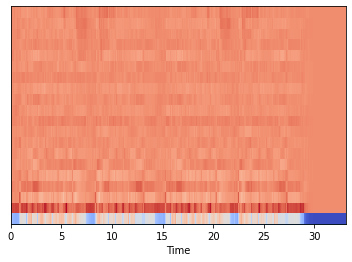

In [ ]:
#4. Mel-Frequency Cepstral Coefficients : The Mel frequency cepstral coefficients (MFCCs) of a signal are a small set of features (usually about 10–20) which concisely describe the overall shape of a spectral envelope.
x, fs = librosa.load('/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/Carnatic raga dataset/Anandabhairavi/song_1.mp3')
librosa.display.waveplot(x, sr=sr)
mfccs = librosa.feature.mfcc(x, sr=fs)
print (mfccs.shape)
(20, 97)
#Displaying  the MFCCs:
librosa.display.specshow(mfccs, sr=sr, x_axis='time')

/usr/local/lib/python3.7/dist-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


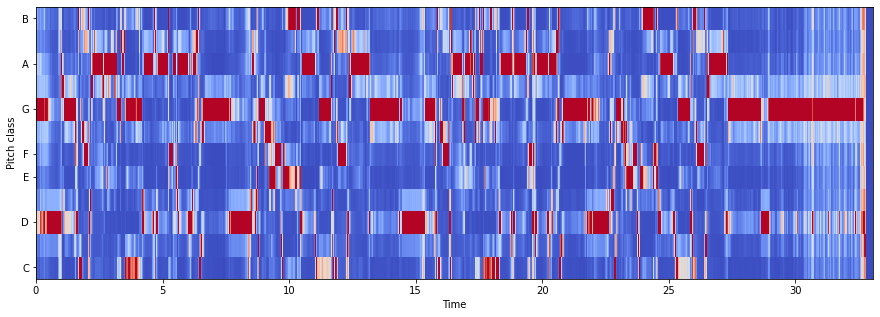

In [ ]:
#5. Chroma Frequencies : Chroma features are an interesting and powerful representation for music audio in which the entire spectrum is projected onto 12 bins representing the 12 distinct semitones (or chroma) of the musical octave.
# Loadign the file
x, sr = librosa.load('/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/Carnatic raga dataset/Anandabhairavi/song_1.mp3')
hop_length = 512
chromagram = librosa.feature.chroma_stft(x, sr=sr, hop_length=hop_length)
plt.figure(figsize=(15, 5))
librosa.display.specshow(chromagram, x_axis='time', y_axis='chroma', hop_length=hop_length, cmap='coolwarm')

/usr/local/lib/python3.7/dist-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


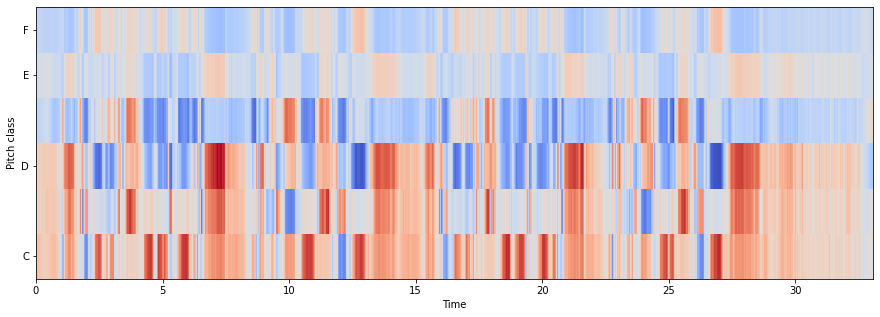

In [ ]:
#6 tonnetz
x, sr = librosa.load('/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/Carnatic raga dataset/Anandabhairavi/song_1.mp3')
hop_length = 512
tonnetz = librosa.feature.tonnetz(x, sr=sr, hop_length=hop_length)
plt.figure(figsize=(15, 5))
librosa.display.specshow(tonnetz, x_axis='time', y_axis='chroma', hop_length=hop_length, cmap='coolwarm')

/usr/local/lib/python3.7/dist-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


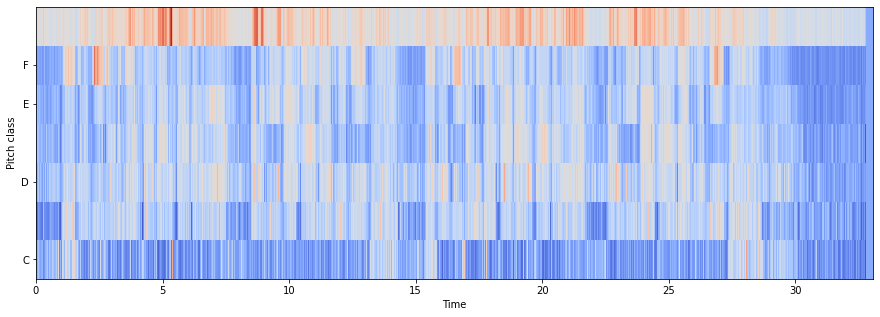

In [ ]:
#7 spectral-contrast
x, sr = librosa.load('/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/Carnatic raga dataset/Anandabhairavi/song_1.mp3')
hop_length = 512
spectral_contrast = librosa.feature.spectral_contrast(x, sr=sr, hop_length=hop_length)
plt.figure(figsize=(15, 5))
librosa.display.specshow(spectral_contrast, x_axis='time', y_axis='chroma', hop_length=hop_length, cmap='coolwarm')

/usr/local/lib/python3.7/dist-packages/librosa/core/audio.py:162: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")


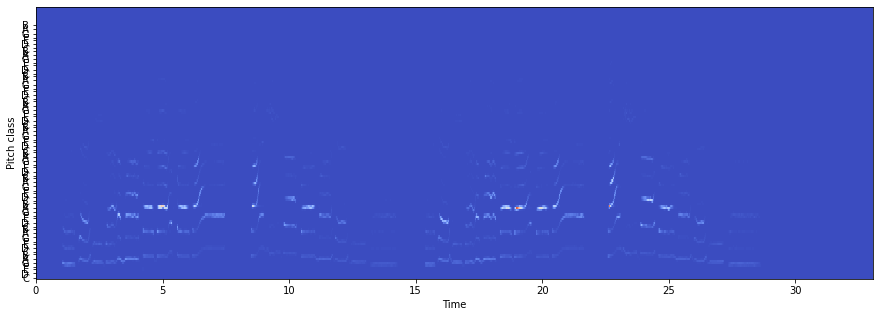

In [ ]:
#8 melspectrogram
x, sr = librosa.load('/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/Carnatic raga dataset/Anandabhairavi/song_1.mp3')
hop_length = 512
mel = librosa.feature.melspectrogram(x, sr=sr, hop_length=hop_length)
plt.figure(figsize=(15, 5))
librosa.display.specshow(mel, x_axis='time', y_axis='chroma', hop_length=hop_length, cmap='coolwarm')

dataset visualization

In [ ]:
header = 'filename chroma_stft rmse spectral_centroid spectral_bandwidth rolloff zero_crossing_rate contrast mel tonnetz'
for i in range(1, 41):
    header += f' mfcc{i}'
header += ' label'
header = header.split()

In [ ]:
#We write the data to a csv file

file = open('raga_recog_dataset.csv', 'w', newline='')
with file:
    writer = csv.writer(file)
    writer.writerow(header)
genres = 'Anandabhairavi Atana Bageda Bhairavai Bilahari Dhanyasi Hamsadhwani Harikambodhi Hindolam Kalyani Kambodhi Kharaharapriya Madhyamavathi Mayamalavagowla Mohanam Mukhari Natakurunji Panthuvarali Purvikalyani Reethigowla'.split()
for g in genres:
    for filename in os.listdir(f'/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/Carnatic raga dataset/{g}'):
        songname = f'/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/Carnatic raga dataset/{g}/{filename}'
        y, sr = librosa.load(songname, mono=True, duration=40)
        rmse = librosa.feature.rms(y=y)
        chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
        spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)
        spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y)
        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        melspectrogram = librosa.feature.melspectrogram(y=y, sr=sr)
        tonnetz = librosa.feature.tonnetz(y=y, sr=sr)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        to_append = f'{filename} {np.mean(chroma_stft)} {np.mean(rmse)} {np.mean(spec_cent)} {np.mean(spec_bw)} {np.mean(rolloff)} {np.mean(zcr)} {np.mean(spectral_contrast)} {np.mean(melspectrogram)} {np.mean(tonnetz)}'    
        for e in mfcc:
            to_append += f' {np.mean(e)}'
        to_append += f' {g}'
        file = open('raga_recog_dataset.csv', 'a', newline='')
        with file:
            writer = csv.writer(file)
            writer.writerow(to_append.split())

In [8]:
import pandas as pd

In [9]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/raga_recog_dataset_Phase-II.csv')

In [10]:
df

,filename,chroma_stft,rmse,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,contrast,mel,tonnetz,mfcc1,mfcc2,mfcc3,mfcc4,mfcc5,mfcc6,mfcc7,mfcc8,mfcc9,mfcc10,mfcc11,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,mfcc21,mfcc22,mfcc23,mfcc24,mfcc25,mfcc26,mfcc27,mfcc28,mfcc29,mfcc30,mfcc31,mfcc32,mfcc33,mfcc34,mfcc35,mfcc36,mfcc37,mfcc38,mfcc39,mfcc40,label
0,song_28.mp3,0.274206,0.155100,1598.124810,1850.970943,3185.995496,0.056514,23.134254,6.264009,0.024662,-167.682816,108.983337,-22.076075,35.297249,-3.312627,0.444070,-6.939825,1.151313,-13.242552,9.098583,-7.832334,-6.213546,-9.012344,2.401376,-9.850040,-3.043397,-10.177035,1.358721,-7.357073,0.422068,-4.691611,-4.403484,-6.671139,-1.334601,-5.797785,-0.656703,-3.552661,-1.206563,-6.073332,-2.044290,-7.326188,-0.644316,2.161919,5.415533,3.520072,7.160343,5.209234,2.723176,2.225262,1.659635,Anandabhairavi
1,song_27.mp3,0.215429,0.525738,1505.879504,1893.770914,2843.201399,0.051371,22.574448,72.820206,0.019200,-60.983105,115.202065,-8.599236,27.822208,1.163367,-14.807601,-7.422687,-3.146727,-21.509050,-0.999473,-11.504626,-3.512163,-1.865144,-1.851349,-5.267570,-3.548113,-5.820648,2.801030,-4.150241,-3.198728,-6.362967,-7.500464,-6.631664,-1.590041,-4.467941,-3.824237,-4.983335,-1.952609,-1.942388,5.233437,5.716955,10.514295,9.462333,7.703338,3.535779,3.848125,4.156825,5.969550,2.446384,1.250155,Anandabhairavi
2,song_29.mp3,0.237845,0.672849,1784.991408,2069.266018,3533.476157,0.054747,21.043100,120.541473,0.005213,-16.560774,98.302727,-13.709867,24.726294,-3.036094,-8.435711,-3.636306,-3.557181,-12.880523,-3.016002,-11.143339,-7.143221,-4.788669,-1.801925,-2.607754,1.248317,-0.611403,1.200247,-3.187017,-1.650672,-2.759074,-2.184091,-4.163511,-1.220172,-3.822064,-1.149249,-3.233911,-2.068057,-0.826490,4.066833,7.391893,10.889918,9.528884,7.795704,4.569308,5.203630,3.601874,5.444336,4.154684,3.132570,Anandabhairavi
3,song_7.mp3,0.303620,0.057367,1453.941696,1170.692650,2516.129165,0.105633,28.883067,0.887843,0.060824,-247.455521,137.145737,-75.109200,15.418835,-24.910748,-25.454830,-35.614925,-44.455936,-9.132675,-10.896485,-6.559312,-26.874365,-21.379980,1.582419,-1.183431,-7.866126,-14.687433,-2.191859,-9.260876,-3.560874,3.012328,-14.379135,-1.059402,-1.975005,-10.003238,-10.502950,-8.396460,6.148086,0.302269,0.065898,0.011451,-6.735325,-4.049429,-5.591233,-1.608224,-4.688880,-4.201306,2.607306,-1.974147,-2.727457,Anandabhairavi
4,song_26.mp3,0.215570,0.204862,1188.483301,1531.778305,2042.186239,0.051179,23.649567,10.602968,-0.012334,-141.688767,142.539398,-10.551584,16.046398,-26.600452,2.454040,1.861583,2.050166,-12.918335,3.886387,-1.561368,-5.311874,-11.899229,0.585678,-3.118896,-0.439662,-7.616439,-0.243282,-6.936875,-2.909155,-8.237361,-2.462110,-8.889487,-5.415492,-6.633533,6.675288,13.598409,21.168535,16.971458,15.715361,3.032575,-5.572026,-6.391319,4.366990,5.827260,2.358907,-4.803684,-3.615998,-0.058192,6.469366,Anandabhairavi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,song_25.mp3,0.223745,0.096109,1790.208198,1933.370765,3497.670802,0.063781,24.562011,3.068096,0.025297,-238.615448,90.400185,-34.539326,21.507036,-17.544773,-19.668306,-12.705247,-18.386032,-23.944073,-13.820561,-19.936552,-4.353498,-18.077129,1.842018,-0.860293,-15.093869,2.704350,-7.022518,-11.711380,-9.287390,-10.228944,-9.170725,-6.514760,-4.119253,-4.327611,1.580533,-0.234174,8.841179,-0.230228,11.624892,3.794180,7.206067,4.893110,2.775811,5.910505,5.556123,0.598006,-1.112370,-3.768898,-1.527829,Reethigowla
596,song_11.mp3,0.223745,0.096109,1790.208198,1933.370765,3497.670802,0.063781,24.562011,3.068096,0.025297,-238.615448,90.400185,-34.539326,21.507036,-17.544773,-19.668306,-12.705247,-18.386032,-23.944073,-13.820561,-19.936552,-4.353498,-18.077129,1.842018,-0.860293,-15.093869,2.704350,-7.022518

In [11]:
df.head()

,filename,chroma_stft,rmse,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,contrast,mel,tonnetz,mfcc1,mfcc2,mfcc3,mfcc4,mfcc5,mfcc6,mfcc7,mfcc8,mfcc9,mfcc10,mfcc11,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,mfcc21,mfcc22,mfcc23,mfcc24,mfcc25,mfcc26,mfcc27,mfcc28,mfcc29,mfcc30,mfcc31,mfcc32,mfcc33,mfcc34,mfcc35,mfcc36,mfcc37,mfcc38,mfcc39,mfcc40,label
0,song_28.mp3,0.274206,0.155100,1598.124810,1850.970943,3185.995496,0.056514,23.134254,6.264009,0.024662,-167.682816,108.983337,-22.076075,35.297249,-3.312627,0.444070,-6.939825,1.151313,-13.242552,9.098583,-7.832334,-6.213546,-9.012344,2.401376,-9.850040,-3.043397,-10.177035,1.358721,-7.357073,0.422068,-4.691611,-4.403484,-6.671139,-1.334601,-5.797785,-0.656703,-3.552661,-1.206563,-6.073332,-2.044290,-7.326188,-0.644316,2.161919,5.415533,3.520072,7.160343,5.209234,2.723176,2.225262,1.659635,Anandabhairavi
1,song_27.mp3,0.215429,0.525738,1505.879504,1893.770914,2843.201399,0.051371,22.574448,72.820206,0.019200,-60.983105,115.202065,-8.599236,27.822208,1.163367,-14.807601,-7.422687,-3.146727,-21.509050,-0.999473,-11.504626,-3.512163,-1.865144,-1.851349,-5.267570,-3.548113,-5.820648,2.801030,-4.150241,-3.198728,-6.362967,-7.500464,-6.631664,-1.590041,-4.467941,-3.824237,-4.983335,-1.952609,-1.942388,5.233437,5.716955,10.514295,9.462333,7.703338,3.535779,3.848125,4.156825,5.969550,2.446384,1.250155,Anandabhairavi
2,song_29.mp3,0.237845,0.672849,1784.991408,2069.266018,3533.476157,0.054747,21.043100,120.541473,0.005213,-16.560774,98.302727,-13.709867,24.726294,-3.036094,-8.435711,-3.636306,-3.557181,-12.880523,-3.016002,-11.143339,-7.143221,-4.788669,-1.801925,-2.607754,1.248317,-0.611403,1.200247,-3.187017,-1.650672,-2.759074,-2.184091,-4.163511,-1.220172,-3.822064,-1.149249,-3.233911,-2.068057,-0.826490,4.066833,7.391893,10.889918,9.528884,7.795704,4.569308,5.203630,3.601874,5.444336,4.154684,3.132570,Anandabhairavi
3,song_7.mp3,0.303620,0.057367,1453.941696,1170.692650,2516.129165,0.105633,28.883067,0.887843,0.060824,-247.455521,137.145737,-75.109200,15.418835,-24.910748,-25.454830,-35.614925,-44.455936,-9.132675,-10.896485,-6.559312,-26.874365,-21.379980,1.582419,-1.183431,-7.866126,-14.687433,-2.191859,-9.260876,-3.560874,3.012328,-14.379135,-1.059402,-1.975005,-10.003238,-10.502950,-8.396460,6.148086,0.302269,0.065898,0.011451,-6.735325,-4.049429,-5.591233,-1.608224,-4.688880,-4.201306,2.607306,-1.974147,-2.727457,Anandabhairavi
4,song_26.mp3,0.215570,0.204862,1188.483301,1531.778305,2042.186239,0.051179,23.649567,10.602968,-0.012334,-141.688767,142.539398,-10.551584,16.046398,-26.600452,2.454040,1.861583,2.050166,-12.918335,3.886387,-1.561368,-5.311874,-11.899229,0.585678,-3.118896,-0.439662,-7.616439,-0.243282,-6.936875,-2.909155,-8.237361,-2.462110,-8.889487,-5.415492,-6.633533,6.675288,13.598409,21.168535,16.971458,15.715361,3.032575,-5.572026,-6.391319,4.366990,5.827260,2.358907,-4.803684,-3.615998,-0.058192,6.469366,Anandabhairavi


In [12]:
df = df.drop(['filename'],axis=1)

In [13]:
dataset = df.values
dataset

array([[0.274206281, 0.155099511, 1598.12481, ..., 2.2252616880000002,
        1.659635425, 'Anandabhairavi'],
       [0.21542909699999999, 0.52573812, 1505.879504, ..., 2.446383715,
        1.250154734, 'Anandabhairavi'],
       [0.237844571, 0.672849238, 1784.9914079999999, ..., 4.154684067,
        3.1325695510000005, 'Anandabhairavi'],
       ...,
       [0.223745152, 0.09610935300000001, 1790.208198, ..., -3.768898249,
        -1.5278289319999998, 'Reethigowla'],
       [0.223745152, 0.09610935300000001, 1790.208198, ..., -3.768898249,
        -1.5278289319999998, 'Reethigowla'],
       [0.223745152, 0.09610935300000001, 1790.208198, ..., -3.768898249,
        -1.5278289319999998, 'Reethigowla']], dtype=object)

In [14]:
X = dataset[:,0:49]

In [15]:
X

array([[0.274206281, 0.155099511, 1598.12481, ..., 2.7231762410000004,
        2.2252616880000002, 1.659635425],
       [0.21542909699999999, 0.52573812, 1505.879504, ...,
        5.969550132999999, 2.446383715, 1.250154734],
       [0.237844571, 0.672849238, 1784.9914079999999, ...,
        5.4443364139999995, 4.154684067, 3.1325695510000005],
       ...,
       [0.223745152, 0.09610935300000001, 1790.208198, ..., -1.112370133,
        -3.768898249, -1.5278289319999998],
       [0.223745152, 0.09610935300000001, 1790.208198, ..., -1.112370133,
        -3.768898249, -1.5278289319999998],
       [0.223745152, 0.09610935300000001, 1790.208198, ..., -1.112370133,
        -3.768898249, -1.5278289319999998]], dtype=object)

In [16]:
Y = dataset[:,49]
Y

array(['Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi',
       'Anandabhairavi', 'Anandabhairavi', 'Anandabhairavi', 'Atana',
       'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana',
       'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana',
       'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana',
       'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana', 'Atana',
       'Atana', 'Bageda', 'Bageda', 'Bageda', 'Bageda', 'Bageda',
       'Bageda', 'Bageda', 'Bageda'

In [17]:
genre_list = df.iloc[:, 49]
encoder = LabelEncoder()
Y = encoder.fit_transform(genre_list)

In [18]:
Y

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  5,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7

In [19]:
print(len(X))
print(len(Y))

600
600


In [20]:
from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler()
X_scale = min_max_scaler.fit_transform(X)

In [21]:
X_scale

array([[0.32800961, 0.20729576, 0.504694  , ..., 0.43929282, 0.55627028,
        0.50457247],
       [0.09501565, 0.73772514, 0.46742032, ..., 0.59070173, 0.56410805,
        0.48507208],
       [0.18387105, 0.94825922, 0.58020142, ..., 0.56620608, 0.62465953,
        0.5747169 ],
       ...,
       [0.12798066, 0.12287359, 0.58230938, ..., 0.26040525, 0.34380458,
        0.35277825],
       [0.12798066, 0.12287359, 0.58230938, ..., 0.26040525, 0.34380458,
        0.35277825],
       [0.12798066, 0.12287359, 0.58230938, ..., 0.26040525, 0.34380458,
        0.35277825]])

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_val_and_test, Y_train, Y_val_and_test = train_test_split(X_scale, Y, test_size=0.2)

In [24]:
print (X_train)
print(len(X_train))

[[0.09720379 0.15949523 0.85069616 ... 0.19047662 0.16092864 0.22588921]
 [0.34907934 0.09253365 0.27861669 ... 0.40598438 0.54949185 0.58288806]
 [0.79823261 0.02109859 0.57655824 ... 0.31554131 0.33393331 0.35374444]
 ...
 [0.12798066 0.12287359 0.58230938 ... 0.26040525 0.34380458 0.35277825]
 [0.13440726 0.12365117 0.81443718 ... 0.29097132 0.0907328  0.31273456]
 [0.50429791 0.12344148 0.16674565 ... 0.04961647 0.28429066 0.26018167]]
480


In [25]:
print (X_val_and_test)
print(len(X_val_and_test ))

[[0.18026397 0.10126398 0.91575389 ... 0.2666994  0.39922384 0.21710798]
 [0.19496949 0.1174072  0.89219808 ... 0.27933532 0.20961447 0.24179996]
 [0.114686   0.14433044 0.85524992 ... 0.26113916 0.27773454 0.24562868]
 ...
 [0.23213161 0.72302828 0.48995613 ... 0.67527983 0.6729705  0.60287205]
 [0.147621   0.14930144 0.86567714 ... 0.24340427 0.34982081 0.17658627]
 [0.44460482 0.06742908 0.44643374 ... 0.43388871 0.40742036 0.29564928]]
120


In [26]:
print (Y_train)
print(len(X_val_and_test ))

[ 9  6  6  9 13  4 13 17  2  9  0 19 16 15  3  5 11  8 15  5 18 19  6 11
  3  4  2 11  9  1 13  7  7 13 16 11  9 13  7  0  5 10 14  5 12 15  0  5
 12 16 14 11  2 16 16  9  8  4 19 17  8  8 16 15 17 10 18 15 17  0 12  4
  2 16  8 16  7  0  6 17 10 15  6 12  0  5  8 15  4  9 14 12  1 16 15 14
  7  2  2  2  8 17 14  1 18 17  7 12  8  6 19 14  5 11 19 19 16 10 13 17
  2 10 10 16 10 16 18  8 12  6  7 17  8  9 18  1  8 10 14  5  9 16 19 19
 19  5  0 15  1 10 11  2  2  1 17 19 12  3  2 13 15  9  8  4 11 11 13  4
  3  1 13  4 11 15  7  6  3 13  5 19 10  7 16  2  2  9 11  5 11 11  3  9
 12  9  2 14  4  6  8 13 13 10  8 13 12  5 11  2 12 17  1 19  0 15 18  8
  7  3 18  7 15 16 11  7  5  8 10  3 17 14 13  5 17  6  4 13  2 12 14  3
 18 10 18  1  9  9  5  7 14 12  7 15 14  0  7 10  3 18  5 11  9  3  4 15
 15  3  1  1  0 14 12 14  8  8 10 16  4  3 18  6  9  6  9 10  8  4 11  7
  9 15 16  2  4  1 12  6  4 12  7 14 19  5  3  1  6 10 12 15 11  3 19  6
  6  0 14 10  6 15  1  0 10 11  8  1  4  4  3 18 13

In [27]:
print (Y_val_and_test)
print(len(X_val_and_test ))

[ 8 16  0  6 12 17 19 11  8  0  2  0 11  9  0 17  9  5 17 14 13 18 17 15
  2  1 14  0  9  6 10  4  0 14 14  2  6  4  5  7  1 16  3  2 12 13 18  7
 13 11  7  2  6 18 10  0 19 17  1  8 12 12  3 14  6  8 15 13  3 17 17 18
 14  6  1 12  5  7  6 18 16  5  9  3  5  1  1 11 17 13 19  3 13 18  8  6
  9 12 16 13  6  7  0  3 11 18  9 15  6 12  0  9 14  7 19 13  5 13 13  0]
120


In [28]:
X_val, X_test, Y_val, Y_test = train_test_split(X_val_and_test, Y_val_and_test, test_size=0.5)

In [29]:
print(len(X_val))
print(len(X_test))
print(len(Y_val))
print(len(Y_test ))

60
60
60
60


In [30]:
print(X_train.shape, X_val.shape, X_test.shape, Y_train.shape, Y_val.shape, Y_test.shape)

(480, 49) (60, 49) (60, 49) (480,) (60,) (60,)


simple Neural Netwoek

In [31]:
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential([
                    Dense(32, activation='relu', input_shape=(49,)),
                    Dense(32, activation='relu'),
                    Dense(20, activation='sigmoid')
])

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_3 (Dense)              (None, 32)                1600      
_________________________________________________________________
dense_4 (Dense)              (None, 32)                1056      
_________________________________________________________________
dense_5 (Dense)              (None, 20)                660       
Total params: 3,316
Trainable params: 3,316
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
import keras
from matplotlib import pyplot as plt
history = model.fit(X_train, Y_train, batch_size=10, epochs=200, validation_data=(X_val, Y_val))


Epoch 1/200
48/48 [==============================] - 0s 4ms/step - loss: 0.0051 - accuracy: 0.9958 - val_loss: 5.1291 - val_accuracy: 0.7000
Epoch 2/200
48/48 [==============================] - 0s 3ms/step - loss: 0.0057 - accuracy: 0.9979 - val_loss: 5.1618 - val_accuracy: 0.7000
Epoch 3/200
48/48 [==============================] - 0s 2ms/step - loss: 0.0058 - accuracy: 0.9979 - val_loss: 5.1697 - val_accuracy: 0.7000
Epoch 4/200
48/48 [==============================] - 0s 2ms/step - loss: 0.0053 - accuracy: 0.9979 - val_loss: 5.1636 - val_accuracy: 0.7000
Epoch 5/200
48/48 [==============================] - 0s 3ms/step - loss: 0.0054 - accuracy: 0.9979 - val_loss: 5.1686 - val_accuracy: 0.7000
Epoch 6/200
48/48 [==============================] - 0s 2ms/step - loss: 0.0059 - accuracy: 0.9958 - val_loss: 5.1495 - val_accuracy: 0.7000
Epoch 7/200
48/48 [==============================] - 0s 3ms/step - loss: 0.0060 - accuracy: 0.9958 - val_loss: 5.1481 - val_accuracy: 0.7000
Epoch 8/200
4

In [ ]:
model.evaluate(X_test, Y_test)

2/2 [==============================] - 0s 8ms/step - loss: 5.2267 - accuracy: 0.7167


[5.2267303466796875, 0.7166666388511658]

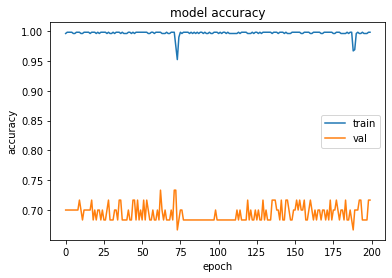

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='best')
plt.show()

LSTM

In [32]:
import os
import librosa
import pandas as pd
import csv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import keras
import tensorflow.keras.layers as layers
import keras
import tensorflow as tf
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Flatten
from keras.optimizers import Adam
from keras.layers import Bidirectional
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Model


In [34]:

input_shape = (X_train.shape[1], X_train.shape[2])
model = Sequential()
adam1 = Adam(learning_rate=0.0009)
model.add(LSTM(units=128, dropout=0.05, recurrent_dropout=0.25, return_sequences=True,input_shape=input_shape))
model.add(LSTM(units=64,  dropout=0.05, recurrent_dropout=0.25, return_sequences=True))
model.add(Flatten())
model.add(Dense(units=20, activation="softmax"))
model.compile(loss="sparse_categorical_crossentropy", optimizer=adam1, metrics=["accuracy"],)
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 1, 128)            91136     
_________________________________________________________________
lstm_1 (LSTM)                (None, 1, 64)             49408     
_________________________________________________________________
flatten (Flatten)            (None, 64)                0         
_________________________________________________________________
dense (Dense)                (None, 20)                1300      
Total params: 141,844
Trainable params: 141,844
Non-trainable params: 0
_________________________________________________________________


In [36]:
from keras.utils.vis_utils import plot_model

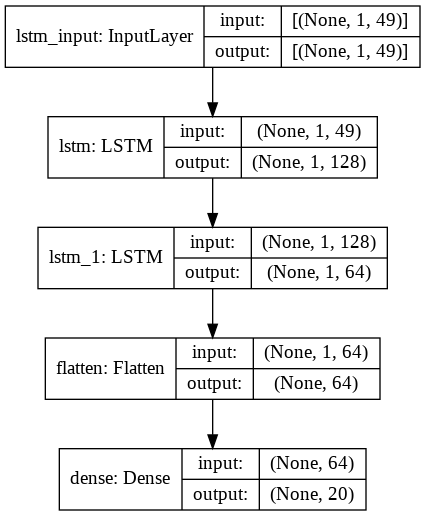

In [37]:
plot_model(model, to_file='model_plot_LSTM.png', show_shapes=True, show_layer_names=True)

In [ ]:
batch_size = 10 # num of training examples per minibatch
num_epochs =200
classify2 = model.fit(
    X_train,
    Y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_data=(X_test,Y_test),
)

Epoch 1/200
48/48 [==============================] - 4s 18ms/step - loss: 2.9943 - accuracy: 0.0538 - val_loss: 2.9940 - val_accuracy: 0.0833
Epoch 2/200
48/48 [==============================] - 0s 6ms/step - loss: 2.9859 - accuracy: 0.0881 - val_loss: 2.9857 - val_accuracy: 0.0500
Epoch 3/200
48/48 [==============================] - 0s 6ms/step - loss: 2.9629 - accuracy: 0.0828 - val_loss: 2.9473 - val_accuracy: 0.1000
Epoch 4/200
48/48 [==============================] - 0s 6ms/step - loss: 2.9072 - accuracy: 0.1509 - val_loss: 2.8272 - val_accuracy: 0.1333
Epoch 5/200
48/48 [==============================] - 0s 6ms/step - loss: 2.7914 - accuracy: 0.1419 - val_loss: 2.6209 - val_accuracy: 0.2833
Epoch 6/200
48/48 [==============================] - 0s 5ms/step - loss: 2.5718 - accuracy: 0.2309 - val_loss: 2.4104 - val_accuracy: 0.3333
Epoch 7/200
48/48 [==============================] - 0s 5ms/step - loss: 2.4379 - accuracy: 0.2912 - val_loss: 2.2889 - val_accuracy: 0.3833
Epoch 8/200


In [ ]:
model.evaluate(X_test, Y_test)

2/2 [==============================] - 1s 6ms/step - loss: 0.3940 - accuracy: 0.9167


[0.394040584564209, 0.9166666865348816]

CNN 

In [ ]:
pip install split_folders

In [ ]:
import splitfolders
# To only split into training and validation set, set a tuple to `ratio`, i.e, `(.7, .3)`.
splitfolders.ratio('/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/Spec_image_dataset/', output="./data", seed=1337, ratio=(.7, .3)) # default values

Copying files: 600 files [00:03, 195.33 files/s]


In [42]:
from keras.models import Sequential
from keras.layers.convolutional import Conv3D
from keras.layers.convolutional_recurrent import ConvLSTM2D
from keras.layers.normalization import BatchNormalization
from keras.preprocessing.image import img_to_array, array_to_img
from keras.preprocessing.image import load_img
import numpy as np
import pylab as plt

In [100]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/raga_recog_dataset_Phase-II.csv')
# Dropping unneccesary columns
data = data.drop(['filename'],axis=1)
#Encoding the Labels
raga_list = data.iloc[:, -1]
encoder = LabelEncoder()
Y = encoder.fit_transform(raga_list)
#Scaling the Feature columns
scaler = StandardScaler()
X = scaler.fit_transform(np.array(data.iloc[:, :-1], dtype = float))
#Dividing data into training and Testing set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
input_shape = (X_train.shape[1], X_train.shape[2])
X_train.shape[1], X_train.shape[2]

(1, 49)

In [104]:
model = tf.keras.Sequential()
model.add(layers.Conv1D(64,3, activation = "relu",padding = 'same', input_shape=input_shape))
model.add(layers.Conv1D(32,3,activation = 'relu',padding = 'same'))
model.add(layers.Flatten())
model.add(layers.Dropout(0.3))
model.add(layers.Dense(64,activation = 'relu'))
model.add(layers.Dense(20,activation = 'softmax'))
model.summary()

Model: "sequential_15"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_20 (Conv1D)           (None, 1, 64)             9472      
_________________________________________________________________
conv1d_21 (Conv1D)           (None, 1, 32)             6176      
_________________________________________________________________
flatten_13 (Flatten)         (None, 32)                0         
_________________________________________________________________
dropout_16 (Dropout)         (None, 32)                0         
_________________________________________________________________
dense_21 (Dense)             (None, 64)                2112      
_________________________________________________________________
dense_22 (Dense)             (None, 20)                1300      
Total params: 19,060
Trainable params: 19,060
Non-trainable params: 0
_________________________________________________

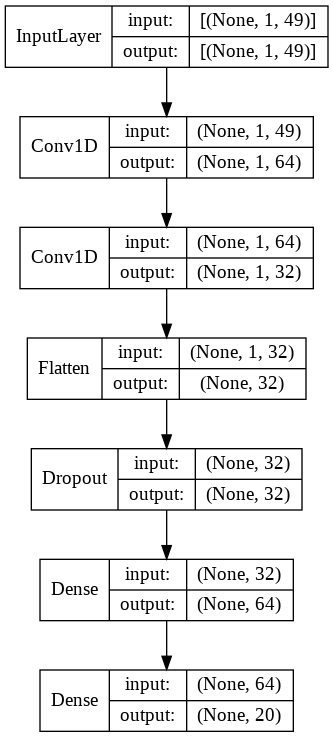

In [105]:
plot_model(model, to_file='model_plot_CNN_.png', show_shapes=True, show_layer_names=False)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
classifier = model.fit(X_train, y_train,batch_size=10, epochs=200, validation_data=(X_test,y_test))

Epoch 1/200
45/45 [==============================] - 1s 6ms/step - loss: 2.9685 - accuracy: 0.0772 - val_loss: 2.8942 - val_accuracy: 0.2267
Epoch 2/200
45/45 [==============================] - 0s 3ms/step - loss: 2.7656 - accuracy: 0.2684 - val_loss: 2.7251 - val_accuracy: 0.2933
Epoch 3/200
45/45 [==============================] - 0s 3ms/step - loss: 2.5111 - accuracy: 0.2777 - val_loss: 2.4211 - val_accuracy: 0.3800
Epoch 4/200
45/45 [==============================] - 0s 3ms/step - loss: 2.0558 - accuracy: 0.4390 - val_loss: 2.0282 - val_accuracy: 0.4067
Epoch 5/200
45/45 [==============================] - 0s 3ms/step - loss: 1.7359 - accuracy: 0.5371 - val_loss: 1.7202 - val_accuracy: 0.5733
Epoch 6/200
45/45 [==============================] - 0s 3ms/step - loss: 1.4634 - accuracy: 0.5641 - val_loss: 1.5804 - val_accuracy: 0.6133
Epoch 7/200
45/45 [==============================] - 0s 3ms/step - loss: 1.2268 - accuracy: 0.6796 - val_loss: 1.4675 - val_accuracy: 0.6333
Epoch 8/200
4

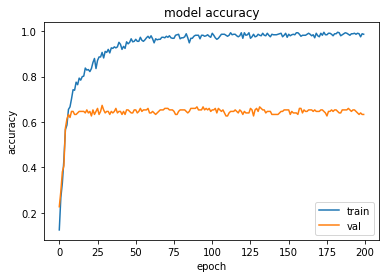

In [ ]:
history = classifier

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='best')
plt.show()

CNN-lstm

In [88]:
#Analysing the Data in Pandas¶
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ME Project Raga recognition/raga_recog_dataset_Phase-II.csv')
data.head()
# Dropping unneccesary columns
data = data.drop(['filename'],axis=1)
#Encoding the Labels¶
genre_list = data.iloc[:, -1]
encoder = LabelEncoder()
y = encoder.fit_transform(genre_list)

#Scaling the Feature columns¶
scaler = StandardScaler()
X = scaler.fit_transform(np.array(data.iloc[:, :-1], dtype = float))
#Dividing data into training and Testing set¶
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# print(X_train)
# print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
# print(X_test)

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
input_shape = (X_train.shape[1], X_train.shape[2])

In [94]:
def make_cnn_lstm_model(lstm_neurons,dense_neurons,drop_out):
  model = Sequential()
  model.add(Conv1D(60,32, strides=1, activation='relu',padding='causal',input_shape=(None, 49, 1)))
  model.add(Conv1D(80,10, strides=1, activation='relu',padding='causal'))
  model.add(TimeDistributed(Dropout(drop_out)))
  model.add(TimeDistributed(MaxPooling1D(pool_size=2)))
  model.add(TimeDistributed(Flatten()))
  model.add(LSTM(lstm_neurons))
  model.add(Dropout(drop_out)) 
  model.add(Dense(dense_neurons, activation='softmax'))
  model.add(Dense(units=20, activation="softmax"))
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model
  

In [89]:
X_train, X_test, Y_train, y_test = train_test_split(X, Y, test_size=0.25)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
input_shape = (X_train.shape[1], X_train.shape[2])

In [48]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D
from keras.layers import MaxPooling1D
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers import TimeDistributed
from keras.optimizers import Adam
from keras.layers import Bidirectional
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [93]:
model_cnn_lstm = make_cnn_lstm_model(lstm_neurons= 100, dense_neurons = 100, drop_out = 0.5)
print(model_cnn_lstm.summary())

Model: "sequential_13"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_16 (Conv1D)           (None, None, 49, 60)      1980      
_________________________________________________________________
conv1d_17 (Conv1D)           (None, None, 49, 80)      48080     
_________________________________________________________________
time_distributed_17 (TimeDis (None, None, 49, 80)      0         
_________________________________________________________________
time_distributed_18 (TimeDis (None, None, 24, 80)      0         
_________________________________________________________________
time_distributed_19 (TimeDis (None, None, 1920)        0         
_________________________________________________________________
lstm_13 (LSTM)               (None, 100)               808400    
_________________________________________________________________
dropout_14 (Dropout)         (None, 100)             

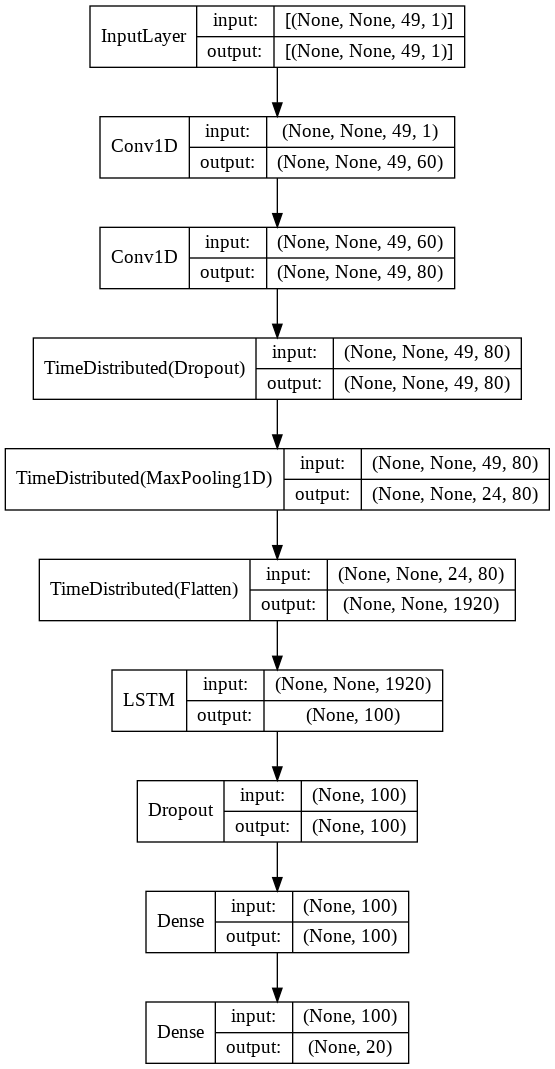

In [95]:
plot_model(model_cnn_lstm, to_file='model_plot2.png', show_shapes=True, show_layer_names=False)

In [96]:
classifier = model.fit(X_train, y_train,batch_size=10, epochs=200, validation_data=(X_test,y_test))
# Evaluation on the test set
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))
scores = model.evaluate(X_train, y_train, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Epoch 1/200
45/45 [==============================] - 1s 12ms/step - loss: 4.6589 - accuracy: 0.1600 - val_loss: 3.0398 - val_accuracy: 0.4333
Epoch 2/200
45/45 [==============================] - 1s 12ms/step - loss: 1.9805 - accuracy: 0.5356 - val_loss: 1.9533 - val_accuracy: 0.6533
Epoch 3/200
45/45 [==============================] - 1s 12ms/step - loss: 1.1241 - accuracy: 0.7444 - val_loss: 1.5366 - val_accuracy: 0.7133
Epoch 4/200
45/45 [==============================] - 1s 12ms/step - loss: 0.7245 - accuracy: 0.8444 - val_loss: 1.4124 - val_accuracy: 0.7000
Epoch 5/200
45/45 [==============================] - 1s 12ms/step - loss: 0.4987 - accuracy: 0.9156 - val_loss: 1.3734 - val_accuracy: 0.7133
Epoch 6/200
45/45 [==============================] - 1s 12ms/step - loss: 0.3733 - accuracy: 0.9444 - val_loss: 1.3572 - val_accuracy: 0.7133
Epoch 7/200
45/45 [==============================] - 1s 11ms/step - loss: 0.2851 - accuracy: 0.9689 - val_loss: 1.4199 - val_accuracy: 0.7067
Epoch 

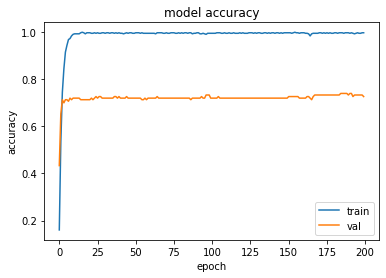

In [97]:
history = classifier
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='best')
plt.show()

**Bi -directional LSTM**

In [78]:

model = Sequential()
adam1 = Adam(learning_rate=0.0009)
model.add(Bidirectional(LSTM(units=128, dropout=0.05, recurrent_dropout=0.25, return_sequences=True), input_shape=input_shape))
model.add(Bidirectional(LSTM(units=64,  dropout=0.05, recurrent_dropout=0.25, return_sequences=True)))
model.add(Flatten())
model.add(Dense(units=20, activation="softmax"))
model.compile(loss="sparse_categorical_crossentropy", optimizer=adam1, metrics=["accuracy"],)
model.summary()

Model: "sequential_11"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
bidirectional_4 (Bidirection (None, 1, 256)            182272    
_________________________________________________________________
bidirectional_5 (Bidirection (None, 1, 128)            164352    
_________________________________________________________________
flatten_10 (Flatten)         (None, 128)               0         
_________________________________________________________________
dense_17 (Dense)             (None, 20)                2580      
Total params: 349,204
Trainable params: 349,204
Non-trainable params: 0
_________________________________________________________________


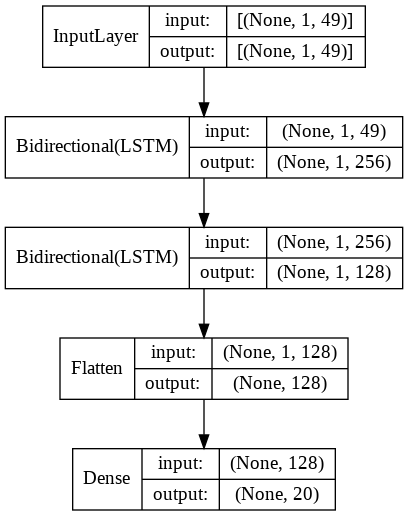

In [79]:
plot_model(model, to_file='bi-LSTM.png', show_shapes=True, show_layer_names=False)

In [ ]:

batch_size = 35 # num of training examples per minibatch
num_epochs =200
classify = model.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_data=(X_test,y_test),
)

Epoch 1/200
13/13 [==============================] - 0s 20ms/step - loss: 0.0035 - accuracy: 0.9978 - val_loss: 2.4074 - val_accuracy: 0.6533
Epoch 2/200
13/13 [==============================] - 0s 19ms/step - loss: 0.0041 - accuracy: 0.9956 - val_loss: 2.4070 - val_accuracy: 0.6533
Epoch 3/200
13/13 [==============================] - 0s 19ms/step - loss: 0.0044 - accuracy: 0.9978 - val_loss: 2.4160 - val_accuracy: 0.6600
Epoch 4/200
13/13 [==============================] - 0s 20ms/step - loss: 0.0039 - accuracy: 0.9978 - val_loss: 2.4255 - val_accuracy: 0.6533
Epoch 5/200
13/13 [==============================] - 0s 21ms/step - loss: 0.0042 - accuracy: 0.9978 - val_loss: 2.4333 - val_accuracy: 0.6533
Epoch 6/200
13/13 [==============================] - 0s 19ms/step - loss: 0.0049 - accuracy: 0.9956 - val_loss: 2.4361 - val_accuracy: 0.6467
Epoch 7/200
13/13 [==============================] - 0s 19ms/step - loss: 0.0038 - accuracy: 0.9978 - val_loss: 2.4354 - val_accuracy: 0.6467
Epoch 

In [ ]:
model.evaluate(X_test, y_test)

5/5 [==============================] - 0s 3ms/step - loss: 2.7224 - accuracy: 0.6533


[2.722402334213257, 0.653333306312561]